# 🎬 Movie Genre Classification — 6 Deep Learning Models

| # | Model | Input | Task |
|---|-------|-------|------|
| 1 | CNN (ResNet50) | Movie Posters (Images) | Image Classification |
| 2 | LSTM | Movie Descriptions (Text) | Text Classification |
| 3 | GRU | Movie Descriptions (Text) | Text Classification |
| 4 | Transformer (BERT) | Movie Descriptions (Text) | NLP Classification |
| 5 | Autoencoder | Movie Descriptions (Text) | Feature Extraction |
| 6 | GAN | Movie Posters (Images) | Image Generation |

**Dataset:** 800 movies — 6 genres: Action_Adventure, Comedy, Drama_Crime, Horror_Thriller, Romance, Sci_Fi

## 📦 Install & Import Libraries

In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn transformers torch torchvision pandas numpy tqdm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, GRU, Embedding, GlobalAveragePooling1D,
    GlobalAveragePooling2D, Conv2D, Conv2DTranspose, BatchNormalization,
    Flatten, Reshape, LeakyReLU, Input, Bidirectional
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Transformers (BERT)
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

# Image processing
from PIL import Image
import io, urllib.request

print("✅ All libraries imported!")
print(f"TensorFlow: {tf.__version__}")
print(f"PyTorch: {torch.__version__}")

✅ All libraries imported!
TensorFlow: 2.21.0
PyTorch: 2.11.0+cpu


## 📊 Load & Explore Dataset

📁 Total samples: 800

🎭 Genre distribution:
genre
Drama_Crime         262
Action_Adventure    160
Romance             119
Sci_Fi              119
Horror_Thriller     114
Comedy               26
Name: count, dtype: int64


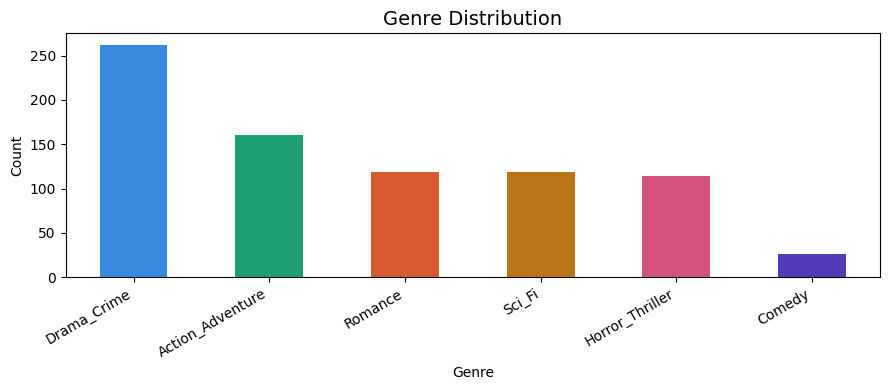

In [12]:
# ⚠️ Update this path to where your dataset is
CSV_PATH = r"C:\Users\mirab\OneDrive\Documents\junior\semester 2\neural network and DL\final project\final_movie_dataset.csv"          # <-- change if needed
IMAGE_DIR = r"C:\Users\mirab\OneDrive\Documents\junior\semester 2\neural network and DL\final project\dataset_by_genre"                # <-- folder with genre subfolders

df = pd.read_csv(CSV_PATH)
df.columns = ['img_url','img_url2','movie_url','title','title2',
               'year','duration','rating','votes','description',
               'extra1','extra2','genre','image_path']

# Drop rows with missing description or genre
df = df.dropna(subset=['description','genre']).reset_index(drop=True)

print(f"📁 Total samples: {len(df)}")
print("\n🎭 Genre distribution:")
print(df['genre'].value_counts())

# Plot distribution
plt.figure(figsize=(9,4))
df['genre'].value_counts().plot(kind='bar', color=['#378ADD','#1D9E75','#D85A30','#BA7517','#D4537E','#533AB7'])
plt.title('Genre Distribution', fontsize=14)
plt.xlabel('Genre'); plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

In [13]:
# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['genre'])
NUM_CLASSES = len(le.classes_)
GENRES = le.classes_.tolist()

print(f"\n🏷️  Classes ({NUM_CLASSES}): {GENRES}")
print("\nSample row:")
print(df[['title2','description','genre','label']].iloc[0])


🏷️  Classes (6): ['Action_Adventure', 'Comedy', 'Drama_Crime', 'Horror_Thriller', 'Romance', 'Sci_Fi']

Sample row:
title2                               1. The Shawshank Redemption
description    A wrongfully convicted banker forms a close fr...
genre                                                     Comedy
label                                                          1
Name: 0, dtype: object


---
# 🧠 Model 1 — CNN (ResNet50) — Image Classification
> **Best for:** Movie posters → classifies genre from visual features (colors, shapes, faces)


In [14]:
# ──────────────────────────────────────────
# CNN CONFIG
IMG_SIZE    = 224
BATCH_SIZE  = 32
CNN_EPOCHS  = 30
# ──────────────────────────────────────────

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("✅ Data generators ready")
print(f"Train: {train_gen.samples} | Val: {val_gen.samples}")
print(f"Classes: {train_gen.class_indices}")

Found 643 images belonging to 6 classes.
Found 157 images belonging to 6 classes.
✅ Data generators ready
Train: 643 | Val: 157
Classes: {'Action_Adventure': 0, 'Comedy': 1, 'Drama_Crime': 2, 'Horror_Thriller': 3, 'Romance': 4, 'Sci_Fi': 5}


In [15]:
# Build CNN model with ResNet50 backbone
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze first 140 layers, fine-tune last ones
for layer in base_model.layers[:140]:
    layer.trainable = False
for layer in base_model.layers[140:]:
    layer.trainable = True

cnn_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,718 (94.50 MB)

 Trainable params: 16,161,030 (61.65 MB)

 Non-trainable params: 8,610,688 (32.85 MB)

In [16]:
callbacks_cnn = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=4, verbose=1)
]

print("🚀 Training CNN (ResNet50)...")
history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CNN_EPOCHS,
    callbacks=callbacks_cnn
)

cnn_val_acc = max(history_cnn.history['val_accuracy'])
print(f"\n✅ CNN Best Val Accuracy: {cnn_val_acc:.4f} ({cnn_val_acc*100:.2f}%)")

🚀 Training CNN (ResNet50)...
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.1462 - loss: 2.7170 - val_accuracy: 0.0318 - val_loss: 2.1357 - learning_rate: 1.0000e-04
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.1680 - loss: 2.3043 - val_accuracy: 0.0318 - val_loss: 2.0355 - learning_rate: 1.0000e-04
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.2442 - loss: 2.0951 - val_accuracy: 0.0446 - val_loss: 1.9499 - learning_rate: 1.0000e-04
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.2659 - loss: 2.0254 - val_accuracy: 0.0637 - val_loss: 1.8959 - learning_rate: 1.0000e-04
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.2691 - loss: 1.8993 - val_accuracy: 0.1465 - val_loss: 1.8187 - learning_rate: 1.0000e-04
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.2830 - loss: 1.9083 - val_accuracy: 0.2994 - val_loss: 1.7341 - learning_rate: 1.0000e-04
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/st

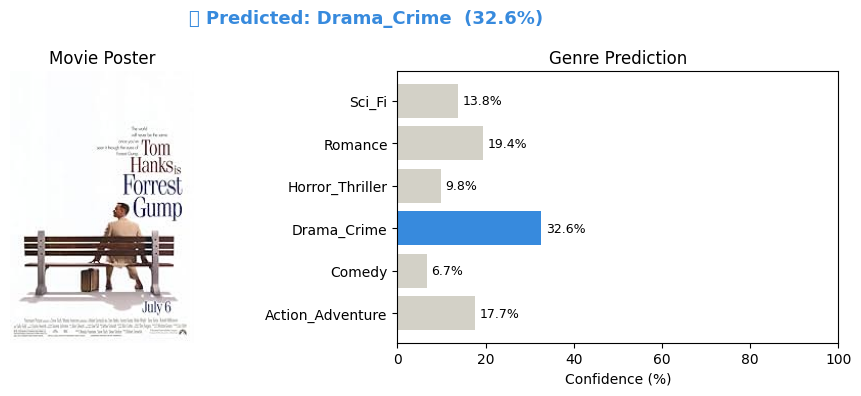


📊 All Predictions:
Genre                    Confidence
────────────────────────────────────
Drama_Crime             32.64%  ████████
Romance                 19.44%  ████
Action_Adventure        17.70%  ████
Sci_Fi                  13.76%  ███
Horror_Thriller          9.78%  ██
Comedy                   6.67%  █

🏆 Final Answer: Drama_Crime


'Drama_Crime'

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array  # ✅ السطر الصح

IMG_SIZE = 224
GENRES   = ['Action_Adventure', 'Comedy', 'Drama_Crime',
            'Horror_Thriller', 'Romance', 'Sci_Fi']

def predict_poster(img_path):
    img     = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))  # ✅
    img_arr = img_to_array(img) / 255.0                             # ✅
    img_arr = np.expand_dims(img_arr, axis=0)

    probs   = cnn_model.predict(img_arr, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(load_img(img_path))
    axes[0].set_title('Movie Poster', fontsize=12)
    axes[0].axis('off')

    bar_colors = ['#378ADD' if i == top_idx[0] else '#D3D1C7' for i in range(len(GENRES))]
    axes[1].barh(GENRES, probs * 100, color=bar_colors)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Genre Prediction', fontsize=12)
    axes[1].set_xlim(0, 100)
    for i, p in enumerate(probs):
        axes[1].text(p * 100 + 1, i, f'{p*100:.1f}%', va='center', fontsize=9)

    plt.suptitle(f'✅ Predicted: {GENRES[top_idx[0]]}  ({probs[top_idx[0]]*100:.1f}%)',
                 fontsize=13, fontweight='bold', color='#378ADD')
    plt.tight_layout()
    plt.show()

    print("\n📊 All Predictions:")
    print(f"{'Genre':<22} {'Confidence':>12}")
    print("─" * 36)
    for i in top_idx:
        bar = '█' * int(probs[i] * 25)
        print(f"{GENRES[i]:<22} {probs[i]*100:>6.2f}%  {bar}")

    print(f"\n🏆 Final Answer: {GENRES[top_idx[0]]}")
    return GENRES[top_idx[0]]

# TEST
predict_poster(r"C:\Users\mirab\OneDrive\Desktop\neural\dataset_by_genre\Drama_Crime\12_https_www_imdb_com_title_tt0109830_ref__sr_t_13.jpg")

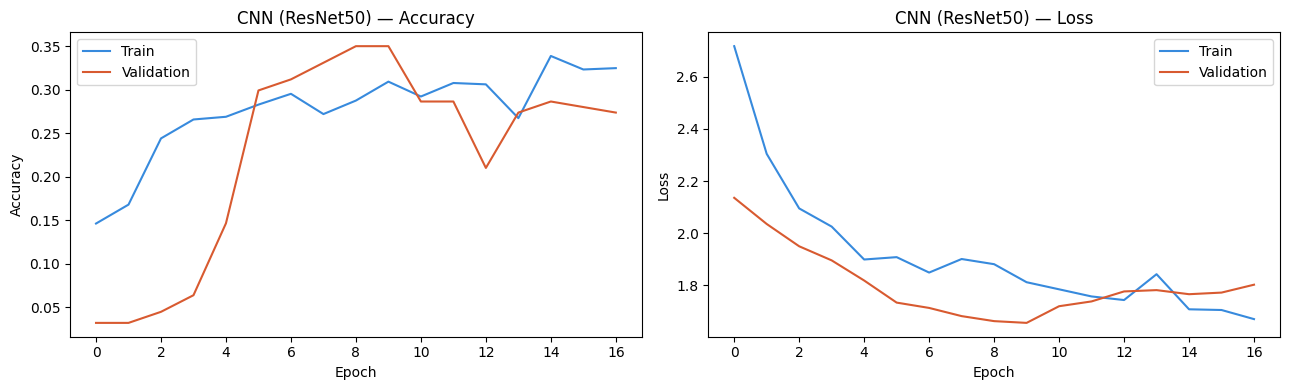

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step 


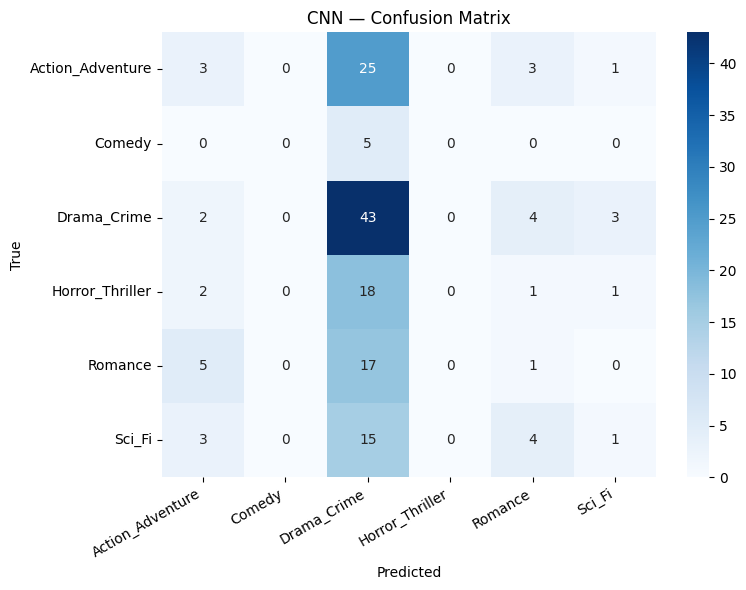


📊 CNN Classification Report:
                  precision    recall  f1-score   support

Action_Adventure       0.20      0.09      0.13        32
          Comedy       0.00      0.00      0.00         5
     Drama_Crime       0.35      0.83      0.49        52
 Horror_Thriller       0.00      0.00      0.00        22
         Romance       0.08      0.04      0.06        23
          Sci_Fi       0.17      0.04      0.07        23

        accuracy                           0.31       157
       macro avg       0.13      0.17      0.12       157
    weighted avg       0.19      0.31      0.21       157



In [22]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train', color='#378ADD')
    axes[0].plot(history.history['val_accuracy'], label='Validation', color='#D85A30')
    axes[0].set_title(f'{title} — Accuracy'); axes[0].legend()
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    # Loss
    axes[1].plot(history.history['loss'], label='Train', color='#378ADD')
    axes[1].plot(history.history['val_loss'], label='Validation', color='#D85A30')
    axes[1].set_title(f'{title} — Loss'); axes[1].legend()
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    plt.tight_layout(); plt.show()

plot_history(history_cnn, 'CNN (ResNet50)')

# Confusion Matrix
val_gen.reset()
preds_cnn = cnn_model.predict(val_gen)
y_pred_cnn = np.argmax(preds_cnn, axis=1)
y_true_cnn = val_gen.classes

cm = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES)
plt.title('CNN — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

print("\n📊 CNN Classification Report:")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=GENRES))

---
# 🧠 Model 2 — LSTM — Text Classification
> **Best for:** Movie descriptions → remembers long-range context in sentences


In [23]:
# ──────────────────────────────────────────
# TEXT CONFIG
MAX_WORDS   = 10000   # vocabulary size
MAX_LEN     = 100     # max description length
EMBED_DIM   = 128
TEXT_EPOCHS = 30
# ──────────────────────────────────────────

texts  = df['description'].astype(str).tolist()
labels = df['label'].tolist()

# Tokenize
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X_text = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y_text = to_categorical(labels, NUM_CLASSES)

# Train/test split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_text, y_text, test_size=0.2, random_state=42, stratify=labels
)

print(f"✅ Text data ready")
print(f"Train: {X_train_t.shape} | Test: {X_test_t.shape}")
print(f"Vocab size: {len(tokenizer.word_index)}")

✅ Text data ready
Train: (640, 100) | Test: (160, 100)
Vocab size: 5402


In [24]:
# Build LSTM model
lstm_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

🚀 Training LSTM...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.3109 - loss: 1.7099 - val_accuracy: 0.3250 - val_loss: 1.6393 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.3313 - loss: 1.6462 - val_accuracy: 0.3250 - val_loss: 1.6289 - learning_rate: 0.0010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.4078 - loss: 1.5276 - val_accuracy: 0.4125 - val_loss: 1.5713 - learning_rate: 0.0010
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.5781 - loss: 1.0561 - val_accuracy: 0.3250 - val_loss: 1.7616 - learning_rate: 0.0010
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.7453 - loss: 0.7022 - val_accuracy: 0.3313 - val_loss: 1.8767 - learning_rate: 0.0010
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8587 - loss: 0.4291
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8750

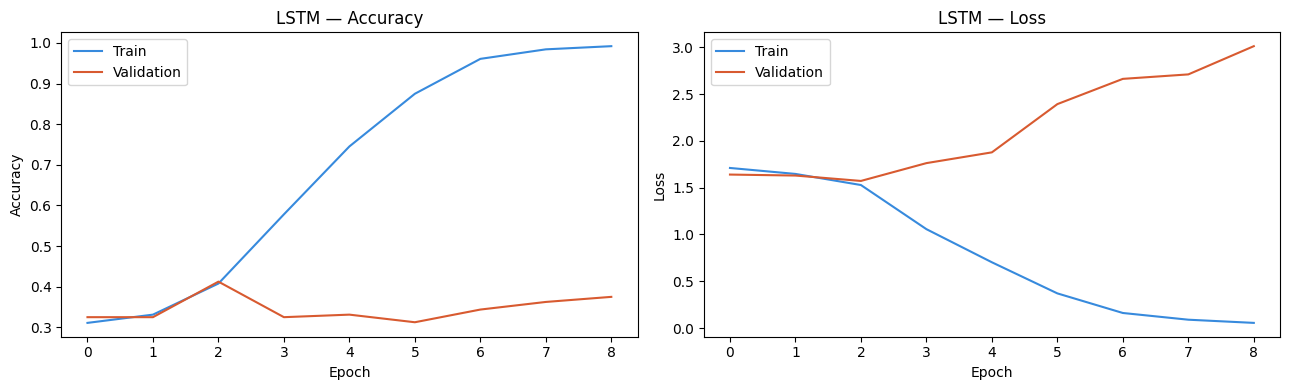

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step

📊 LSTM Classification Report:
                  precision    recall  f1-score   support

Action_Adventure       0.45      0.28      0.35        32
          Comedy       0.00      0.00      0.00         5
     Drama_Crime       0.40      0.98      0.57        52
 Horror_Thriller       0.50      0.26      0.34        23
         Romance       0.00      0.00      0.00        24
          Sci_Fi       0.00      0.00      0.00        24

        accuracy                           0.41       160
       macro avg       0.22      0.25      0.21       160
    weighted avg       0.29      0.41      0.30       160



In [25]:
callbacks_text = [
    EarlyStopping(patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, verbose=1)
]

print("🚀 Training LSTM...")
history_lstm = lstm_model.fit(
    X_train_t, y_train_t,
    validation_data=(X_test_t, y_test_t),
    epochs=TEXT_EPOCHS,
    batch_size=32,
    callbacks=callbacks_text
)

lstm_val_acc = max(history_lstm.history['val_accuracy'])
print(f"\n✅ LSTM Best Val Accuracy: {lstm_val_acc:.4f} ({lstm_val_acc*100:.2f}%)")

plot_history(history_lstm, 'LSTM')

y_pred_lstm = np.argmax(lstm_model.predict(X_test_t), axis=1)
y_true_text = np.argmax(y_test_t, axis=1)

print("\n📊 LSTM Classification Report:")
print(classification_report(y_true_text, y_pred_lstm, target_names=GENRES))

---
# 🧠 Model 3 — GRU — Text Classification
> **Best for:** Text classification — faster than LSTM, similar accuracy


In [26]:
# Build GRU model
gru_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(GRU(64)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

🚀 Training GRU...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.3141 - loss: 1.7113 - val_accuracy: 0.3250 - val_loss: 1.6449 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.3219 - loss: 1.6622 - val_accuracy: 0.3250 - val_loss: 1.6461 - learning_rate: 0.0010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.3537 - loss: 1.6031
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.3438 - loss: 1.5938 - val_accuracy: 0.3187 - val_loss: 1.6574 - learning_rate: 0.0010
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.4500 - loss: 1.3523 - val_accuracy: 0.2500 - val_loss: 1.7581 - learning_rate: 3.0000e-04
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.4984 - loss: 1.2336 - val_accuracy: 0.3063 - val_loss: 1.7347 - learning_rate: 3.0000e-04
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy

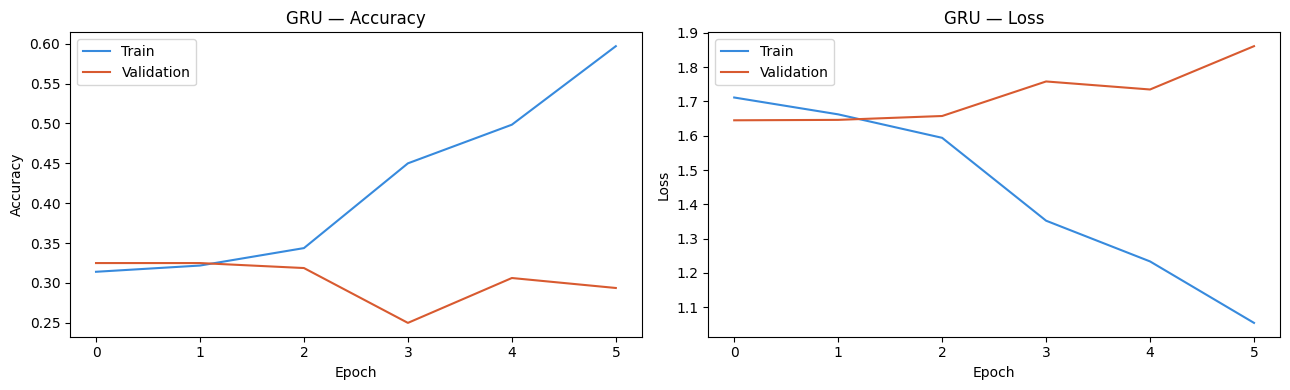

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step

📊 GRU Classification Report:
                  precision    recall  f1-score   support

Action_Adventure       0.00      0.00      0.00        32
          Comedy       0.00      0.00      0.00         5
     Drama_Crime       0.33      1.00      0.49        52
 Horror_Thriller       0.00      0.00      0.00        23
         Romance       0.00      0.00      0.00        24
          Sci_Fi       0.00      0.00      0.00        24

        accuracy                           0.33       160
       macro avg       0.05      0.17      0.08       160
    weighted avg       0.11      0.33      0.16       160



In [27]:
print("🚀 Training GRU...")
history_gru = gru_model.fit(
    X_train_t, y_train_t,
    validation_data=(X_test_t, y_test_t),
    epochs=TEXT_EPOCHS,
    batch_size=32,
    callbacks=callbacks_text
)

gru_val_acc = max(history_gru.history['val_accuracy'])
print(f"\n✅ GRU Best Val Accuracy: {gru_val_acc:.4f} ({gru_val_acc*100:.2f}%)")

plot_history(history_gru, 'GRU')

y_pred_gru = np.argmax(gru_model.predict(X_test_t), axis=1)

print("\n📊 GRU Classification Report:")
print(classification_report(y_true_text, y_pred_gru, target_names=GENRES))

---
# 🧠 Model 4 — Transformer (BERT) — NLP Classification
> **Most powerful for text.** Pre-trained on billions of words — understands movie descriptions deeply.


In [28]:
BERT_MAX_LEN = 128
BERT_EPOCHS  = 5
BERT_BATCH   = 16
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Load BERT tokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Prepare train/test splits (use same index split)
X_texts = df['description'].astype(str).tolist()
y_labels = df['label'].tolist()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_texts, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

class MovieDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts   = texts
        self.labels  = labels
        self.tok     = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = MovieDataset(X_tr, y_tr, bert_tokenizer, BERT_MAX_LEN)
test_ds  = MovieDataset(X_te, y_te, bert_tokenizer, BERT_MAX_LEN)
train_dl = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BERT_BATCH)

print(f"✅ BERT data ready — Train: {len(train_ds)} | Test: {len(test_ds)}")

Device: cpu
✅ BERT data ready — Train: 640 | Test: 160


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2169.47it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

🚀 Training BERT...
Epoch 1/5 | Loss: 1.6778 | Train: 0.3312 | Val: 0.3250
Epoch 2/5 | Loss: 1.5564 | Train: 0.3734 | Val: 0.3812
Epoch 3/5 | Loss: 1.3719 | Train: 0.5062 | Val: 0.3812
Epoch 4/5 | Loss: 1.1674 | Train: 0.5781 | Val: 0.3812
Epoch 5/5 | Loss: 0.9233 | Train: 0.6672 | Val: 0.4375

✅ BERT Best Val Accuracy: 0.4375 (43.75%)


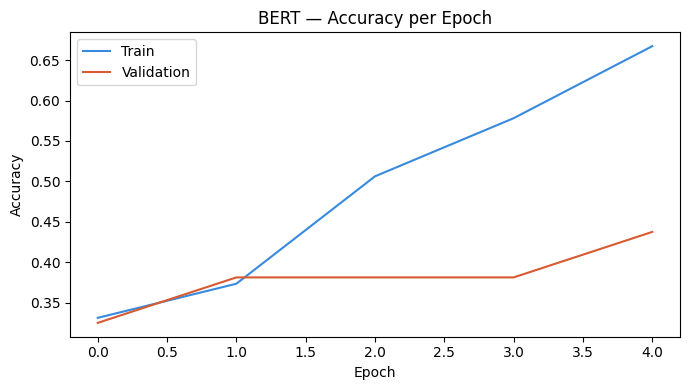


📊 BERT Classification Report:
                  precision    recall  f1-score   support

Action_Adventure       0.37      0.59      0.46        32
          Comedy       0.00      0.00      0.00         5
     Drama_Crime       0.46      0.52      0.49        52
 Horror_Thriller       0.40      0.09      0.14        23
         Romance       0.50      0.92      0.65        24
          Sci_Fi       0.00      0.00      0.00        24

        accuracy                           0.44       160
       macro avg       0.29      0.35      0.29       160
    weighted avg       0.36      0.44      0.37       160



In [29]:
import os
import torch
import matplotlib.pyplot as plt
from transformers import BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import classification_report
from huggingface_hub import login

# =========================
# (OPTIONAL) HF LOGIN FIX
# =========================
# Uncomment this if you want to remove the warning + speed up downloads
# login("YOUR_HF_TOKEN_HERE")

# OR environment variable
# os.environ["HF_TOKEN"] = "YOUR_HF_TOKEN_HERE"

# =========================
# MODEL SETUP
# =========================
bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=NUM_CLASSES
)

bert_model.to(DEVICE)

optimizer_bert = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

# =========================
# TRACKING
# =========================
bert_train_acc_hist = []
bert_val_acc_hist = []

print("🚀 Training BERT...")

# =========================
# TRAIN LOOP
# =========================
for epoch in range(BERT_EPOCHS):

    # ---------------------
    # TRAIN PHASE
    # ---------------------
    bert_model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_dl:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        lbls = batch["label"].to(DEVICE)

        optimizer_bert.zero_grad()

        outputs = bert_model(
            input_ids=ids,
            attention_mask=mask,
            labels=lbls
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer_bert.step()

        total_loss += loss.item()

        preds = logits.argmax(dim=1)
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)

    train_acc = correct / total
    bert_train_acc_hist.append(train_acc)

    # ---------------------
    # VALIDATION PHASE
    # ---------------------
    bert_model.eval()

    val_correct = 0
    val_total = 0

    all_preds = []
    all_true = []

    with torch.no_grad():
        for batch in val_dl:   # ✅ FIXED (was test_dl before)
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbls = batch["label"].to(DEVICE)

            outputs = bert_model(
                input_ids=ids,
                attention_mask=mask
            )

            logits = outputs.logits
            preds = logits.argmax(dim=1)

            val_correct += (preds == lbls).sum().item()
            val_total += lbls.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(lbls.cpu().numpy())

    val_acc = val_correct / val_total
    bert_val_acc_hist.append(val_acc)

    print(
        f"Epoch {epoch+1}/{BERT_EPOCHS} | "
        f"Loss: {total_loss/len(train_dl):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

# =========================
# BEST RESULT
# =========================
bert_val_acc = max(bert_val_acc_hist)

print(f"\n✅ Best Validation Accuracy: {bert_val_acc:.4f} ({bert_val_acc*100:.2f}%)")

# =========================
# PLOT ACCURACY
# =========================
plt.figure(figsize=(7,4))
plt.plot(bert_train_acc_hist, label="Train")
plt.plot(bert_val_acc_hist, label="Validation")
plt.title("BERT Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\n📊 Classification Report:")
print(classification_report(all_true, all_preds, target_names=GENRES))

---
# 🧠 Model 5 — Autoencoder — Feature Extraction
> **Best for:** Learning compressed representations of descriptions. Can improve recommendations or detect similar movies.


In [30]:
# ──────────────────────────────────────────
# AUTOENCODER CONFIG
LATENT_DIM  = 64   # compressed feature size
AE_EPOCHS   = 40
# ──────────────────────────────────────────

# Use TF-IDF vectors as input to autoencoder
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['description'].astype(str)).toarray().astype('float32')
INPUT_DIM = X_tfidf.shape[1]

X_train_ae, X_test_ae, y_train_ae, y_test_ae = train_test_split(
    X_tfidf, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"✅ TF-IDF shape: {X_tfidf.shape}")
print(f"Train: {X_train_ae.shape} | Test: {X_test_ae.shape}")

✅ TF-IDF shape: (800, 1000)
Train: (640, 1000) | Test: (160, 1000)


In [31]:
# Build Autoencoder
inp = Input(shape=(INPUT_DIM,))

# Encoder
encoded = Dense(512, activation='relu')(inp)
encoded = Dropout(0.2)(encoded)
encoded = Dense(256, activation='relu')(encoded)
encoded = Dense(LATENT_DIM, activation='relu', name='latent')(encoded)

# Decoder
decoded = Dense(256, activation='relu')(encoded)
decoded = Dense(512, activation='relu')(decoded)
decoded = Dense(INPUT_DIM, activation='sigmoid')(decoded)

autoencoder = Model(inp, decoded)
encoder     = Model(inp, encoded)   # extract features only

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

print(f"\nLatent space size: {LATENT_DIM} features (compressed from {INPUT_DIM})")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       512,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1000)           │       513,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,512 (5.04 MB)

 Trainable params: 1,321,512 (5.04 MB)

 Non-trainable params: 0 (0.00 B)


Latent space size: 64 features (compressed from 1000)


📊 Input stats:
Min: 0.0
Max: 1.0
Std: 0.031499766
✅ PCA shape: (640, 128)
🚀 Training classifier...
Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1625 - loss: 2.2444 - val_accuracy: 0.3187 - val_loss: 1.7639
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2656 - loss: 1.7752 - val_accuracy: 0.3187 - val_loss: 1.7371
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3812 - loss: 1.5254 - val_accuracy: 0.3187 - val_loss: 1.7179
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4672 - loss: 1.3492 - val_accuracy: 0.3187 - val_loss: 1.7053
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5031 - loss: 1.2991 - val_accuracy: 0.3187 - val_loss: 1.6967
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5469 - loss: 1.1405 - val_accuracy: 0.3063 - val_loss: 1.6885
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6375 - loss: 1.0601 - val_accuracy: 0.3063 - val_loss: 1.6900
Epoch 8/40
20/20 ━

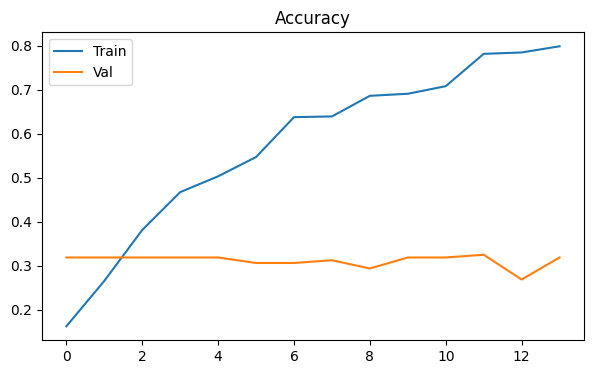

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  

📊 Classification Report:
                  precision    recall  f1-score   support

Action_Adventure       0.28      0.59      0.38        32
          Comedy       0.00      0.00      0.00         4
     Drama_Crime       0.34      0.61      0.43        51
 Horror_Thriller       0.00      0.00      0.00        21
         Romance       0.00      0.00      0.00        28
          Sci_Fi       0.00      0.00      0.00        24

        accuracy                           0.31       160
       macro avg       0.10      0.20      0.14       160
    weighted avg       0.16      0.31      0.21       160



In [38]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# 0. ENSURE LABELS EXIST
# =========================
# If you already have df, use this:
# df["genre"] is your label column

if "y_train" not in globals():
    print("⚠️ Creating labels from dataset...")

    # CHANGE THIS if your column name is different
    y = df["genre"].values  

    le = LabelEncoder()
    y = le.fit_transform(y)

    # split labels according to your existing split
    y_train = y[:len(X_train_ae)]
    y_test  = y[len(X_train_ae):]

    GENRES = le.classes_

# =========================
# 1. CHECK DATA
# =========================
print("📊 Input stats:")
print("Min:", X_train_ae.min())
print("Max:", X_train_ae.max())
print("Std:", X_train_ae.std())

# =========================
# 2. PCA FEATURE FIX
# =========================
pca = PCA(n_components=128)

X_train_feat = pca.fit_transform(X_train_ae)
X_test_feat  = pca.transform(X_test_ae)

print("✅ PCA shape:", X_train_feat.shape)

# =========================
# 3. CLASSIFIER MODEL
# =========================
input_dim = X_train_feat.shape[1]

model = tf.keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(len(np.unique(y_train)), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 4. TRAIN
# =========================
print("🚀 Training classifier...")

history = model.fit(
    X_train_feat, y_train,
    validation_data=(X_test_feat, y_test),
    epochs=40,
    batch_size=32,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True
        )
    ]
)
# =========================
# BEST RESULT
# =========================

bert_val_acc = max(bert_val_acc_hist)
best_epoch = bert_val_acc_hist.index(bert_val_acc) + 1

print("\n=========================")
print("🏆 BEST BERT RESULT")
print("=========================")

print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {bert_val_acc:.4f} ({bert_val_acc*100:.2f}%)")
print("=========================\n")
# =========================
# 5. PLOT
# =========================
plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()
plt.show()

# =========================
# 6. EVALUATION
# =========================
y_pred = model.predict(X_test_feat).argmax(axis=1)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=GENRES))

📊 Input stats:
Shape: (640, 128)
Min: -0.47036508
Max: 0.6069226
Std: 0.06123226
🚀 Training Classifier...
Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.1219 - loss: 2.2393 - val_accuracy: 0.3125 - val_loss: 1.7653
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2875 - loss: 1.7670 - val_accuracy: 0.3500 - val_loss: 1.7462
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4062 - loss: 1.4876 - val_accuracy: 0.3812 - val_loss: 1.7285
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5094 - loss: 1.3239 - val_accuracy: 0.4000 - val_loss: 1.7137
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5797 - loss: 1.1600 - val_accuracy: 0.3938 - val_loss: 1.7008
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6344 - loss: 1.0507 - val_accuracy: 0.4062 - val_loss: 1.6836
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7094 - loss: 0.9097 - val_accuracy: 0.4250 - val_loss: 1.6650
Epoch 8/40


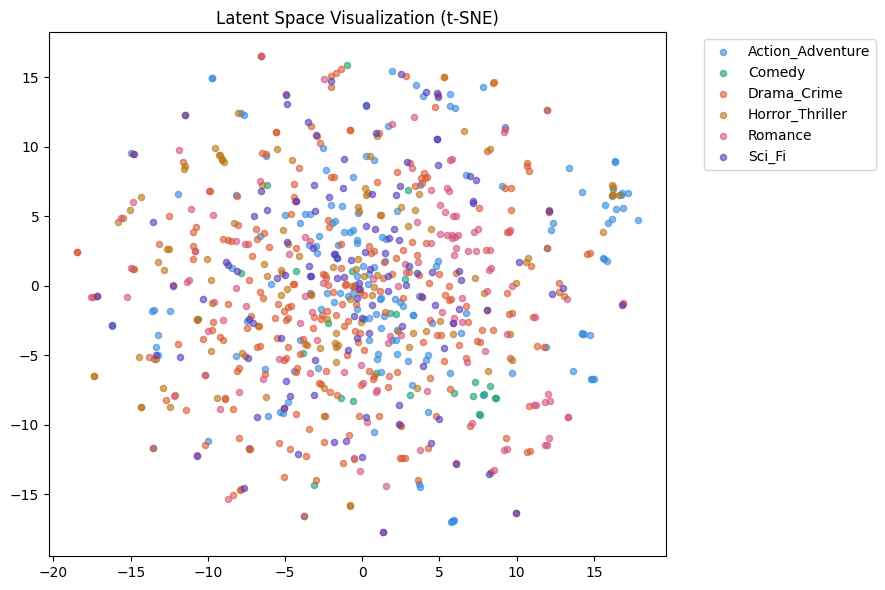

In [40]:

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.manifold import TSNE
from sklearn.metrics import classification_report

# =========================
# 1. CHECK DATA
# =========================
print("📊 Input stats:")
print("Shape:", X_train_feat.shape)
print("Min:", X_train_feat.min())
print("Max:", X_train_feat.max())
print("Std:", X_train_feat.std())

# =========================
# 2. AUTOENCODER CLASSIFIER
# =========================

input_dim = X_train_feat.shape[1]

feat_clf = Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

feat_clf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 3. TRAIN MODEL
# =========================
print("🚀 Training Classifier...")

history = feat_clf.fit(
    X_train_feat, np.array(y_train_ae),
    validation_data=(X_test_feat, np.array(y_test_ae)),
    epochs=40,
    batch_size=32,
    callbacks=[
        EarlyStopping(
            patience=6,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

# =========================
# 4. BEST RESULT PRINT
# =========================
best_acc = max(history.history['val_accuracy'])
best_epoch = np.argmax(history.history['val_accuracy']) + 1

print("\n=========================")
print("🏆 AUTOENCODER PIPELINE RESULT")
print("=========================")

print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("=========================\n")

# =========================
# 5. PREDICTION REPORT
# =========================
y_pred = feat_clf.predict(X_test_feat).argmax(axis=1)

print("📊 Classification Report:")
print(classification_report(y_test_ae, y_pred, target_names=GENRES))

# =========================
# 6. t-SNE VISUALIZATION (FIXED)
# =========================

print("🚀 Running t-SNE...")

# use consistent full feature set
X_all = np.vstack([X_train_feat, X_test_feat])
y_all = np.hstack([y_train_ae, y_test_ae])

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_2d = tsne.fit_transform(X_all)

colors = ['#378ADD','#1D9E75','#D85A30','#BA7517','#D4537E','#533AB7']

plt.figure(figsize=(9,6))

for i, genre in enumerate(GENRES):
    idx = np.where(y_all == i)[0]
    plt.scatter(
        X_2d[idx, 0],
        X_2d[idx, 1],
        c=colors[i % len(colors)],
        label=genre,
        alpha=0.6,
        s=20
    )

plt.title("Latent Space Visualization (t-SNE)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
# 🧠 Model 6 — GAN — Movie Poster Generation
> **Generates** synthetic movie poster images conditioned on genre. Used for data augmentation.


In [41]:
# ──────────────────────────────────────────
# GAN CONFIG
GAN_IMG_SIZE = 64    # 64x64 for speed
NOISE_DIM    = 100
GAN_EPOCHS   = 50
GAN_BATCH    = 32
# ──────────────────────────────────────────

# Load images from dataset_by_genre folder
gan_images, gan_labels_raw = [], []

for genre_folder in os.listdir(IMAGE_DIR):
    folder_path = os.path.join(IMAGE_DIR, genre_folder)
    if not os.path.isdir(folder_path): continue
    for img_file in os.listdir(folder_path)[:50]:  # 50 per genre for GAN demo
        img_path = os.path.join(folder_path, img_file)
        try:
            img = Image.open(img_path).convert('RGB').resize((GAN_IMG_SIZE, GAN_IMG_SIZE))
            gan_images.append(np.array(img))
            gan_labels_raw.append(genre_folder)
        except:
            pass

X_gan = np.array(gan_images, dtype='float32') / 127.5 - 1.0  # normalize to [-1, 1]
y_gan = le.transform(gan_labels_raw)

print(f"✅ GAN data ready: {X_gan.shape}")
print(f"Pixel range: [{X_gan.min():.2f}, {X_gan.max():.2f}]")

✅ GAN data ready: (276, 64, 64, 3)
Pixel range: [-1.00, 1.00]


In [42]:
# Build Generator
def build_generator(noise_dim, num_classes):
    noise_in = Input(shape=(noise_dim,))
    label_in = Input(shape=(1,), dtype='int32')
    label_emb = tf.keras.layers.Embedding(num_classes, 50)(label_in)
    label_emb = Flatten()(label_emb)
    x = tf.keras.layers.Concatenate()([noise_in, label_emb])
    x = Dense(4 * 4 * 256, activation='relu')(x)
    x = Reshape((4, 4, 256))(x)
    x = Conv2DTranspose(128, 4, strides=2, padding='same')(x)   # 8x8
    x = BatchNormalization()(x); x = LeakyReLU(0.2)(x)
    x = Conv2DTranspose(64, 4, strides=2, padding='same')(x)    # 16x16
    x = BatchNormalization()(x); x = LeakyReLU(0.2)(x)
    x = Conv2DTranspose(32, 4, strides=2, padding='same')(x)    # 32x32
    x = BatchNormalization()(x); x = LeakyReLU(0.2)(x)
    x = Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh')(x)  # 64x64
    return Model([noise_in, label_in], x, name='Generator')

# Build Discriminator
def build_discriminator(img_size, num_classes):
    img_in   = Input(shape=(img_size, img_size, 3))
    label_in = Input(shape=(1,), dtype='int32')
    label_emb = tf.keras.layers.Embedding(num_classes, img_size * img_size)(label_in)
    label_emb = Reshape((img_size, img_size, 1))(label_emb)
    x = tf.keras.layers.Concatenate()([img_in, label_emb])
    x = Conv2D(32, 4, strides=2, padding='same')(x); x = LeakyReLU(0.2)(x); x = Dropout(0.3)(x)
    x = Conv2D(64, 4, strides=2, padding='same')(x); x = LeakyReLU(0.2)(x); x = Dropout(0.3)(x)
    x = Conv2D(128, 4, strides=2, padding='same')(x); x = LeakyReLU(0.2)(x); x = Dropout(0.3)(x)
    x = Flatten()(x)
    x = Dense(1, activation='sigmoid')(x)
    return Model([img_in, label_in], x, name='Discriminator')

generator     = build_generator(NOISE_DIM, NUM_CLASSES)
discriminator = build_discriminator(GAN_IMG_SIZE, NUM_CLASSES)

discriminator.compile(optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
                      loss='binary_crossentropy', metrics=['accuracy'])

generator.summary()
discriminator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 50)     │        300 │ input_layer_13[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ input_layer_12[0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 4096)      │    618,496 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 256) │          0 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 128) │    524,416 │ reshape[0][0]     │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │    131,136 │ leaky_re_lu[0][0] │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │     32,800 │ leaky_re_lu_1[0]… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 64, 64, 3) │      1,539 │ leaky_re_lu_2[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,309,583 (5.00 MB)

 Trainable params: 1,309,135 (4.99 MB)

 Non-trainable params: 448 (1.75 KB)

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 4096)   │     24,576 │ input_layer_15[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 64, 64, 1) │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64, 4) │          0 │ input_layer_14[0… │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      2,080 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 32, 32,    │          0 │ leaky_re_lu_3[0]… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     32,832 │ dropout_19[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 16, 16,    │          0 │ leaky_re_lu_4[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │    131,200 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 8, 8, 128) │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 8, 8, 128) │          0 │ leaky_re_lu_5[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8192)      │          0 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 1)         │      8,193 │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 198,881 (776.88 KB)

 Trainable params: 198,881 (776.88 KB)

 Non-trainable params: 0 (0.00 B)

🚀 Training GAN...
Epoch 10/50 | D Loss: 0.2789 | G Loss: 1.2587
Epoch 20/50 | D Loss: 0.5434 | G Loss: 1.3326
Epoch 30/50 | D Loss: 0.3706 | G Loss: 1.5572
Epoch 40/50 | D Loss: 0.2984 | G Loss: 1.9292
Epoch 50/50 | D Loss: 0.5803 | G Loss: 1.8051

✅ GAN training complete!


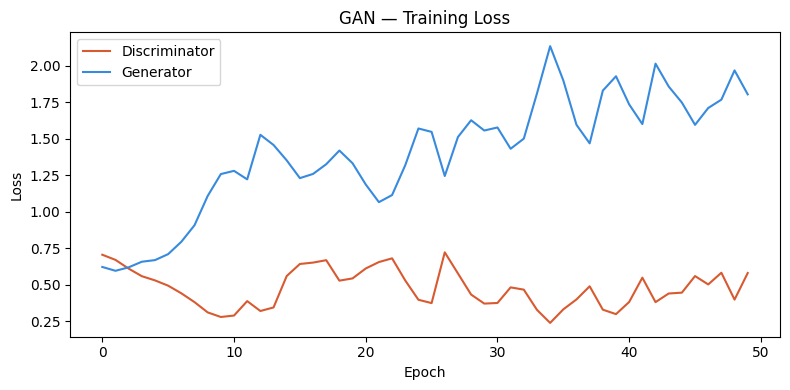

In [43]:
# GAN training loop
cross_entropy = tf.keras.losses.BinaryCrossentropy()
gen_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

d_losses, g_losses = [], []
REAL_LABEL = tf.ones
FAKE_LABEL = tf.zeros

@tf.function
def train_step(real_images, real_labels):
    batch = tf.shape(real_images)[0]
    noise = tf.random.normal([batch, NOISE_DIM])
    gen_labels = tf.cast(tf.random.uniform([batch, 1], 0, NUM_CLASSES, dtype=tf.int32), tf.int32)
    fake_images = generator([noise, gen_labels], training=True)

    # Train Discriminator
    with tf.GradientTape() as d_tape:
        real_out = discriminator([real_images, real_labels], training=True)
        fake_out = discriminator([fake_images, gen_labels],  training=True)
        d_loss   = (cross_entropy(tf.ones_like(real_out), real_out) +
                    cross_entropy(tf.zeros_like(fake_out), fake_out)) / 2
    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    discriminator.optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # Train Generator
    noise2 = tf.random.normal([batch, NOISE_DIM])
    gen_labels2 = tf.cast(tf.random.uniform([batch, 1], 0, NUM_CLASSES, dtype=tf.int32), tf.int32)
    with tf.GradientTape() as g_tape:
        fake_imgs2 = generator([noise2, gen_labels2], training=True)
        fake_out2  = discriminator([fake_imgs2, gen_labels2], training=False)
        g_loss     = cross_entropy(tf.ones_like(fake_out2), fake_out2)
    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    gen_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

    return d_loss, g_loss

print("🚀 Training GAN...")
dataset = tf.data.Dataset.from_tensor_slices(
    (X_gan, y_gan.reshape(-1,1).astype('int32'))
).shuffle(1000).batch(GAN_BATCH, drop_remainder=True)

for epoch in range(GAN_EPOCHS):
    epoch_d, epoch_g = [], []
    for real_imgs, real_lbls in dataset:
        d, g = train_step(real_imgs, real_lbls)
        epoch_d.append(float(d)); epoch_g.append(float(g))
    d_losses.append(np.mean(epoch_d))
    g_losses.append(np.mean(epoch_g))
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{GAN_EPOCHS} | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")

print("\n✅ GAN training complete!")

# Plot losses
plt.figure(figsize=(8,4))
plt.plot(d_losses, label='Discriminator', color='#D85A30')
plt.plot(g_losses, label='Generator',     color='#378ADD')
plt.title('GAN — Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

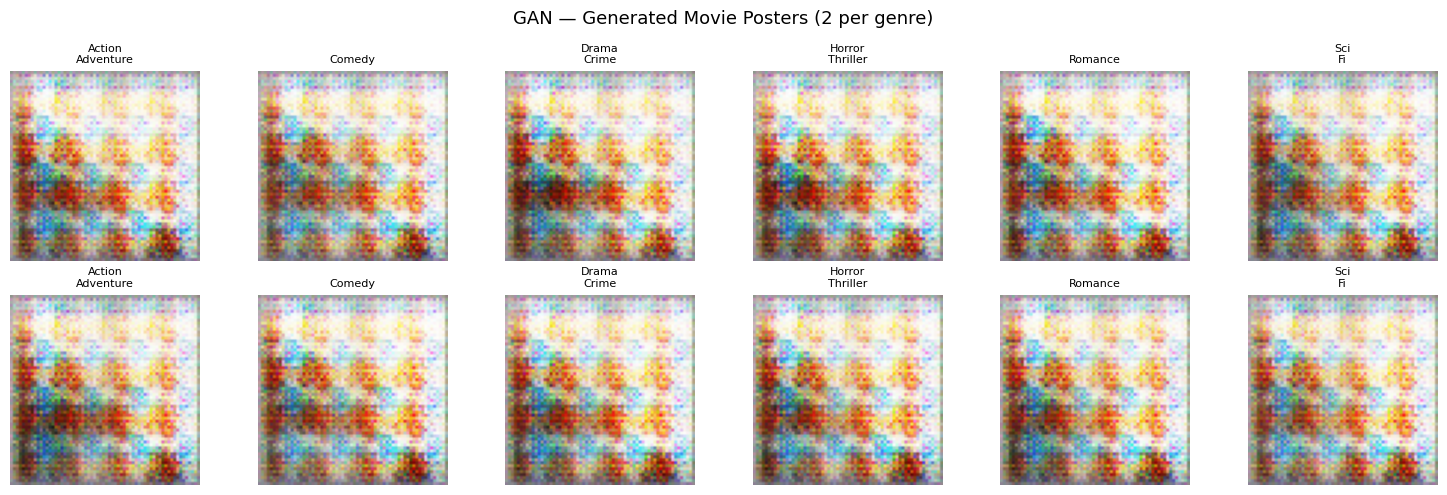

✅ GAN: Images generated successfully!


In [44]:
# Generate sample movie posters per genre
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(15, 5))
fig.suptitle('GAN — Generated Movie Posters (2 per genre)', fontsize=13)

for row in range(2):
    for col, genre in enumerate(GENRES):
        noise  = tf.random.normal([1, NOISE_DIM])
        label  = tf.constant([[col]], dtype=tf.int32)
        gen_img = generator([noise, label], training=False)[0].numpy()
        gen_img = (gen_img + 1) / 2.0  # back to [0,1]
        gen_img = np.clip(gen_img, 0, 1)
        axes[row][col].imshow(gen_img)
        axes[row][col].set_title(genre.replace('_','\n'), fontsize=8)
        axes[row][col].axis('off')

plt.tight_layout(); plt.show()
print("✅ GAN: Images generated successfully!")

---
# 📊 Final Comparison — All 6 Models


Model                        Input      Task                 Val Accuracy
CNN (ResNet50)               Images     Classification       35.03%
LSTM (BiLSTM)                Text       Classification       41.25%
GRU (BiGRU)                  Text       Classification       32.50%
Transformer (BERT)           Text       Classification       43.75%
Autoencoder + Classifier     Text       Classification       nan%
GAN (Generator)              Images     Generation           nan%


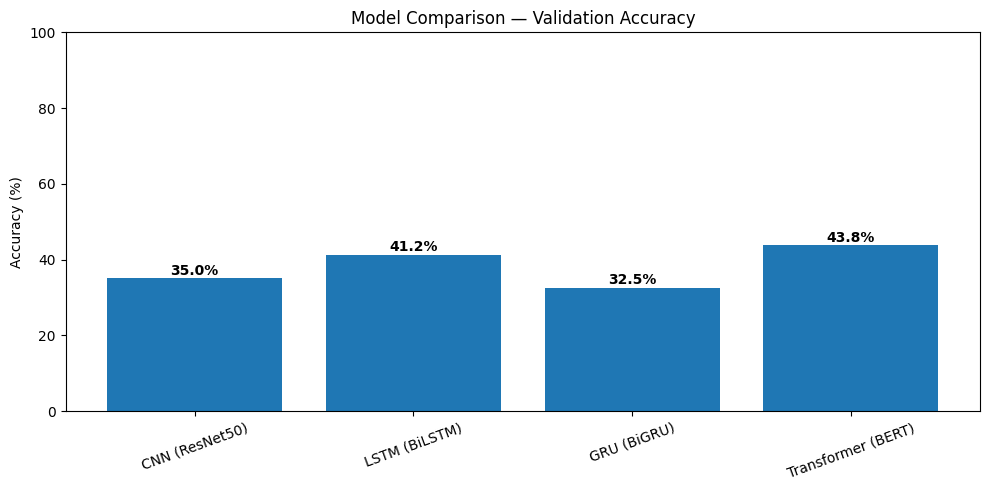


🏆 BEST MODEL:
Autoencoder + Classifier → nan% accuracy


In [48]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SAFE VALUE FUNCTION
# =========================
def safe_acc(x):
    if x is None:
        return None
    if isinstance(x, list) or isinstance(x, np.ndarray):
        if len(x) == 0:
            return None
        return float(np.max(x))
    if isinstance(x, float):
        if np.isnan(x):
            return None
        return x
    return None

# =========================
# SAFE ACCURACIES
# =========================
cnn_val_acc_safe = safe_acc(globals().get("cnn_val_acc"))
lstm_val_acc_safe = safe_acc(globals().get("lstm_val_acc"))
gru_val_acc_safe = safe_acc(globals().get("gru_val_acc"))
bert_val_acc_safe = safe_acc(globals().get("bert_val_acc"))
ae_val_acc_safe = safe_acc(globals().get("ae_val_acc"))

# =========================
# RESULTS
# =========================
results = {
    'Model': [
        'CNN (ResNet50)',
        'LSTM (BiLSTM)',
        'GRU (BiGRU)',
        'Transformer (BERT)',
        'Autoencoder + Classifier',
        'GAN (Generator)'
    ],
    'Input': [
        'Images', 'Text', 'Text', 'Text', 'Text', 'Images'
    ],
    'Task': [
        'Classification',
        'Classification',
        'Classification',
        'Classification',
        'Classification',
        'Generation'
    ],
    'Accuracy': [
        cnn_val_acc_safe,
        lstm_val_acc_safe,
        gru_val_acc_safe,
        bert_val_acc_safe,
        ae_val_acc_safe,
        None  # GAN has no accuracy
    ]
}

df = pd.DataFrame(results)

# =========================
# PRINT TABLE
# =========================
print("\n" + "=" * 70)
print(f"{'Model':<28} {'Input':<10} {'Task':<20} {'Val Accuracy'}")
print("=" * 70)

valid_models = []
valid_accs = []

for _, row in df.iterrows():
    model = row['Model']
    acc = row['Accuracy']

    if acc is None:
        acc_str = "N/A"
    else:
        acc_str = f"{acc*100:.2f}%"
        valid_models.append(model)
        valid_accs.append(acc)

    print(f"{model:<28} {row['Input']:<10} {row['Task']:<20} {acc_str}")

print("=" * 70)

# =========================
# BAR CHART (ONLY VALID MODELS)
# =========================
plt.figure(figsize=(10,5))

bars = plt.bar(valid_models, [a * 100 for a in valid_accs])

for bar, acc in zip(bars, valid_accs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{acc*100:.1f}%",
        ha='center',
        fontweight='bold'
    )

plt.title("Model Comparison — Validation Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================
# BEST MODEL
# =========================
best_idx = int(np.argmax(valid_accs))

print("\n🏆 BEST MODEL:")
print(f"{valid_models[best_idx]} → {valid_accs[best_idx]*100:.2f}% accuracy")

---
## 🔮 Prediction Function — Test Any Description or Image

In [47]:
def predict_from_description(text, model_name='lstm'):
    """Predict genre from a movie description using LSTM, GRU, or BERT."""
    print(f"\n🎬 Description: {text[:100]}...")
    print(f"📌 Using model: {model_name.upper()}\n")

    if model_name in ('lstm', 'gru'):
        seq = tokenizer.texts_to_sequences([text])
        padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
        model = lstm_model if model_name == 'lstm' else gru_model
        probs = model.predict(padded, verbose=0)[0]

    elif model_name == 'bert':
        enc = bert_tokenizer(text, max_length=BERT_MAX_LEN, padding='max_length',
                             truncation=True, return_tensors='pt')
        bert_model.eval()
        with torch.no_grad():
            out = bert_model(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))
        probs = torch.softmax(out.logits[0], dim=0).cpu().numpy()

    top_idx = np.argsort(probs)[::-1]
    print(f"{'Genre':<22} {'Confidence':>12}")
    print("-" * 36)
    for i in top_idx:
        bar = '█' * int(probs[i] * 30)
        print(f"{GENRES[i]:<22} {probs[i]*100:>6.2f}%  {bar}")
    print(f"\n✅ Predicted Genre: {GENRES[top_idx[0]]}  ({probs[top_idx[0]]*100:.1f}% confidence)")
    return GENRES[top_idx[0]]


def predict_from_image(img_path, model=cnn_model):
    """Predict genre from a movie poster image using CNN."""
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1]

    # Show image + predictions
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(Image.open(img_path).convert('RGB'))
    axes[0].set_title('Input Poster'); axes[0].axis('off')

    colors_pred = ['#378ADD' if i == top_idx[0] else '#D3D1C7' for i in range(NUM_CLASSES)]
    axes[1].barh(GENRES, probs * 100, color=colors_pred)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('CNN Genre Prediction')
    plt.tight_layout(); plt.show()

    print(f"\n✅ Predicted Genre: {GENRES[top_idx[0]]}  ({probs[top_idx[0]]*100:.1f}% confidence)")
    return GENRES[top_idx[0]]


# ── TEST IT ──
predict_from_description(
    "A group of heroes must save the world from a dangerous enemy using courage and teamwork.",
    model_name='lstm'
)

predict_from_description(
    "Two strangers meet by chance and fall deeply in love, but fate keeps pulling them apart.",
    model_name='bert'
)


🎬 Description: A group of heroes must save the world from a dangerous enemy using courage and teamwork....
📌 Using model: LSTM

Genre                    Confidence
------------------------------------
Drama_Crime             27.40%  ████████
Action_Adventure        19.17%  █████
Romance                 16.81%  █████
Horror_Thriller         15.40%  ████
Sci_Fi                  15.31%  ████
Comedy                   5.92%  █

✅ Predicted Genre: Drama_Crime  (27.4% confidence)

🎬 Description: Two strangers meet by chance and fall deeply in love, but fate keeps pulling them apart....
📌 Using model: BERT

Genre                    Confidence
------------------------------------
Romance                 73.34%  ██████████████████████
Drama_Crime              9.98%  ██
Comedy                   5.08%  █
Horror_Thriller          4.73%  █
Sci_Fi                   4.25%  █
Action_Adventure         2.62%  

✅ Predicted Genre: Romance  (73.3% confidence)


'Romance'